In [3]:
import tarfile
import urllib.request
from pathlib import Path
import numpy as np
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures,StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib

In [6]:
url = "https://github.com/ageron/data/raw/main/housing.tgz"
tarball_path=Path("datasets/housing.tgz")
tarball_path.parent.mkdir(parents=True, exist_ok=True)
urllib.request.urlretrieve(url,tarball_path)
tarfile.open(tarball_path).extractall("datasets")
housing=pd.read_csv("datasets/housing/housing.csv")
housing.head()


C:\Users\Vishwansh Kumar\AppData\Local\Temp\ipykernel_1692\1590976905.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tarfile.open(tarball_path).extractall("datasets")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [24]:
url = "https://github.com/ageron/data/raw/main/housing.tgz"
tarball_path=Path("datasets/housing.tgz")
tarball_path.parent.mkdir(parents=True, exist_ok=True)
urllib.request.urlretrieve(url,tarball_path)
tarfile.open(tarball_path).extractall("datasets")
housing=pd.read_csv("datasets/housing/housing.csv")
housing.head()

housing=pd.read_csv("datasets/housing/housing.csv")
housing.head()
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


C:\Users\Vishwansh Kumar\AppData\Local\Temp\ipykernel_25884\537239442.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tarfile.open(tarball_path).extractall("datasets")


In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


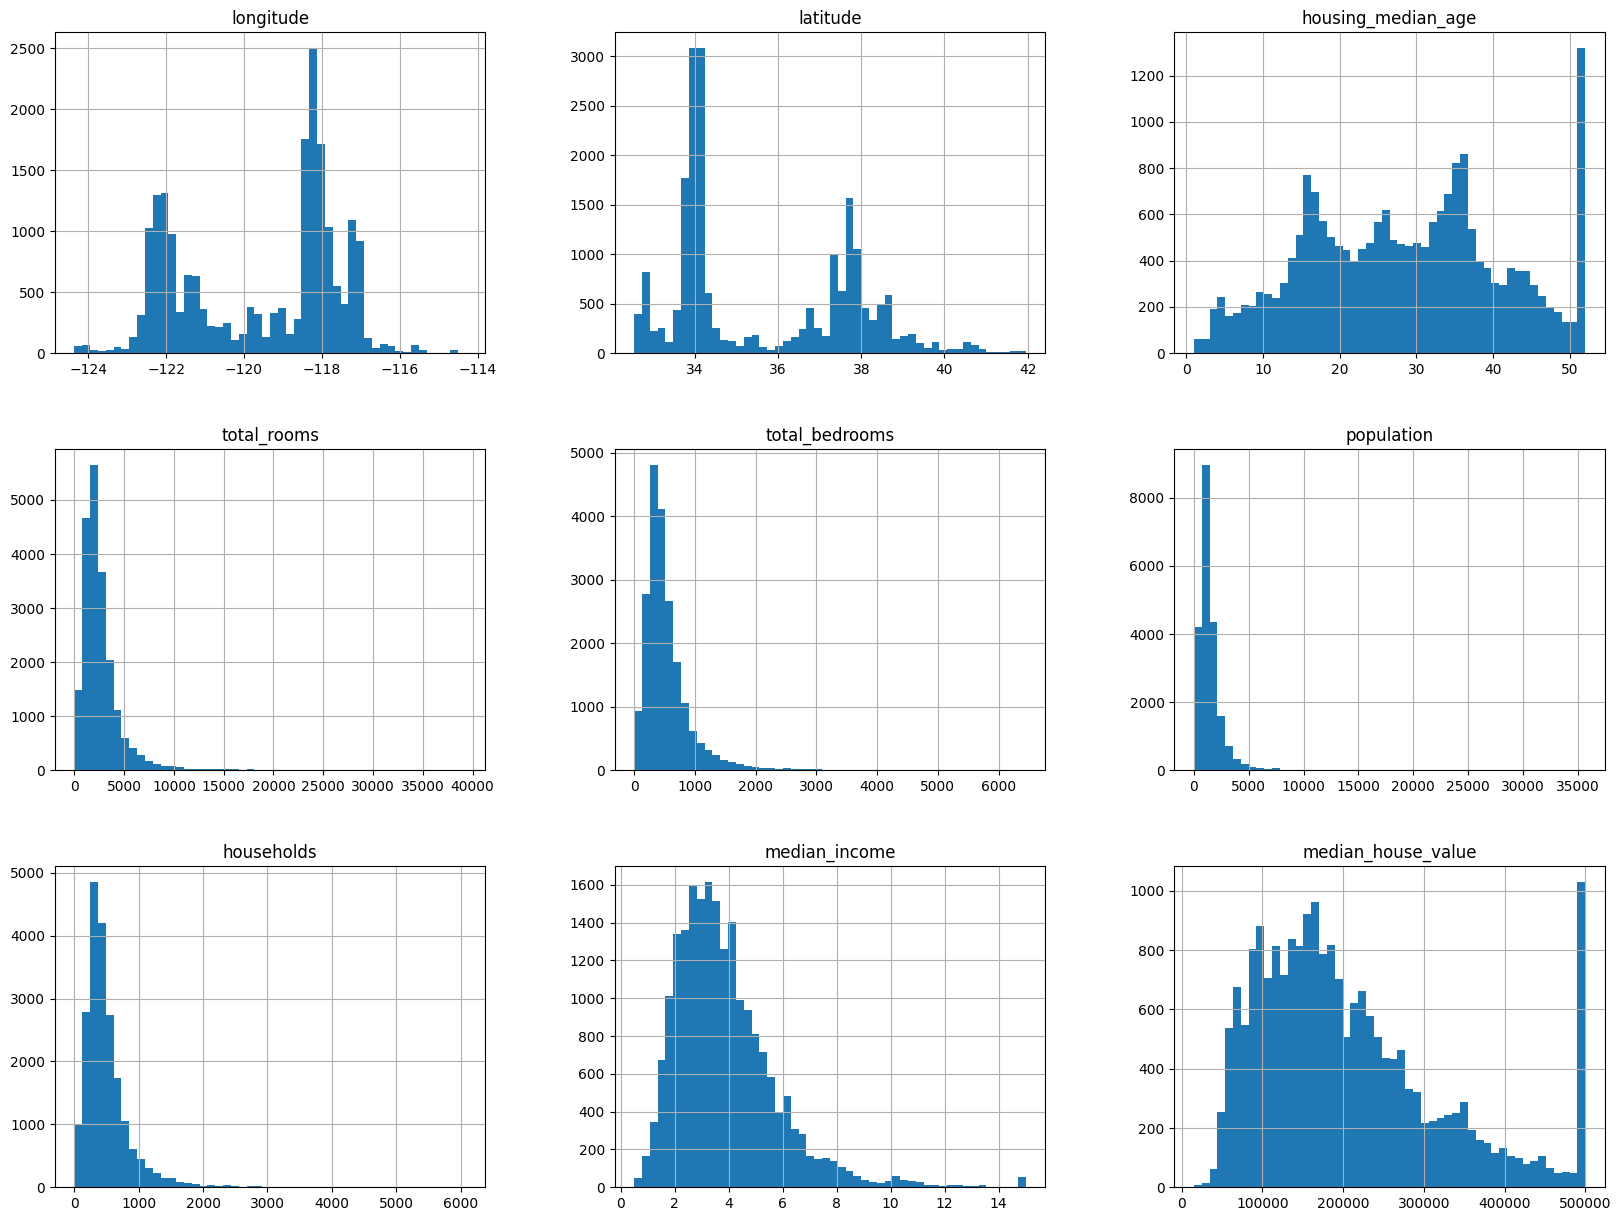

In [9]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [10]:
bins=[0,1.5,3.0,4.5,6.0,np.inf]
housing["income_cat"]=pd.cut(housing["median_income"],bins,labels=[1,2,3,4,5])
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]
housing=housing[housing["median_income"]<500000]
split1=StratifiedShuffleSplit(n_splits=1,test_size=0.2,train_size=0.8,random_state=42)
strat_test_set=[]
strat_trainCV_set=[]
for train_indices,test_indices in split1.split(housing,housing["income_cat"]):
    strat_test_set=housing.iloc[test_indices]
    strat_trainCV_set=housing.iloc[train_indices]
strat_train_set=[]
strat_cv_set=[]
split2=StratifiedShuffleSplit(n_splits=1,test_size=0.25,train_size=0.75,random_state=42)
for train_indices,cv_indices in split2.split(strat_trainCV_set,strat_trainCV_set["income_cat"]):
    strat_train_set=strat_train_set=strat_trainCV_set.iloc[train_indices].copy()
    strat_cv_set=strat_trainCV_set.iloc[cv_indices].copy()
for s in (strat_train_set, strat_cv_set, strat_test_set):
    s.drop("income_cat", axis=1, inplace=True, errors='ignore')

C:\Users\Vishwansh Kumar\AppData\Local\Temp\ipykernel_1692\2071998520.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s.drop("income_cat", axis=1, inplace=True, errors='ignore')


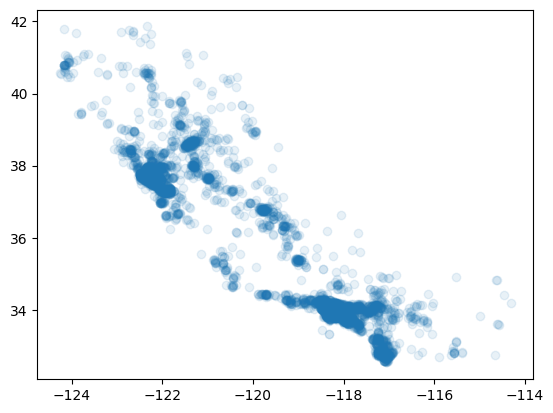

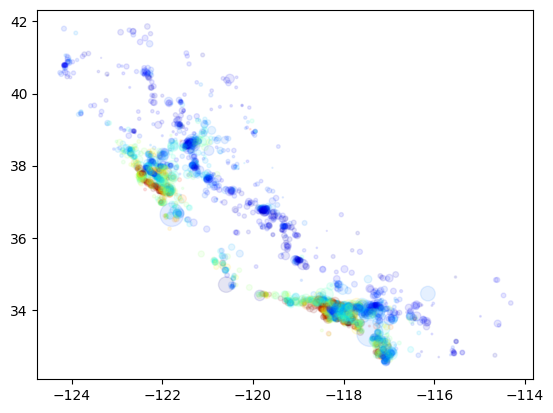

In [11]:
housing=strat_test_set.copy()
plt.scatter(housing["longitude"],housing["latitude"],alpha=0.1)
plt.show()
plt.scatter(housing["longitude"],housing["latitude"],alpha=0.1,s=housing["population"]/100,c=housing["median_house_value"],cmap="jet")


In [12]:
housing=strat_train_set.drop('median_house_value',axis=1)
housing_labels=strat_train_set["median_house_value"].copy()
housing_num=housing.drop("ocean_proximity",axis=1)
#using polynomial regression
num_pipeline=Pipeline([("imputer",SimpleImputer(strategy="median")),("poly",PolynomialFeatures(degree=2,include_bias=False)),("scaler",StandardScaler())])
num_attribs=list(housing_num)
cat_attribs=["ocean_proximity"]

full_pipeline=ColumnTransformer([("num",num_pipeline,num_attribs),("cat",OneHotEncoder(),cat_attribs)])
X_cv_raw = strat_cv_set.drop("median_house_value", axis=1)
housing_labels_cv = strat_cv_set["median_house_value"].copy()
housing_prepared_train=full_pipeline.fit_transform(housing)
housing_prepared_cv=full_pipeline.transform(X_cv_raw)


In [13]:
lin_reg=LinearRegression()
lin_reg.fit(housing_prepared_train,housing_labels)
train_predict=lin_reg.predict(housing_prepared_train)
cv_predict=lin_reg.predict(housing_prepared_cv)
j_train=np.sqrt(mean_squared_error(housing_labels,train_predict))
j_cv=np.sqrt(mean_squared_error(housing_labels_cv,cv_predict))
print(j_train)
print(j_cv)

60784.15542838023
423612.13002731744


high variance, use ridge(regularization)

In [14]:
ridge_reg=Ridge()
ridge_reg.fit(housing_prepared_train,housing_labels)
train_predict_ridge=ridge_reg.predict(housing_prepared_train)
cv_predict_ridge=ridge_reg.predict(housing_prepared_cv)
j_train_ridge=np.sqrt(mean_squared_error(housing_labels,train_predict_ridge))
j_cv_ridge=np.sqrt(mean_squared_error(housing_labels_cv,cv_predict_ridge))
print(j_train_ridge)
print(j_cv_ridge)


62228.074892137636
933314.6127471018


In [15]:
print(housing_prepared_train.shape)
print(housing_prepared_cv.shape)
print("Min prediction:", cv_predict_ridge.min())
print("Max prediction:", cv_predict_ridge.max())
print("Actual Max Price:", housing_labels_cv.max())

(12384, 82)
(4128, 82)
Min prediction: -55575.54962823025
Max prediction: 59154100.7038368
Actual Max Price: 500001.0


In [16]:
xgb_reg = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, # Smaller learning rate is better with early stopping
    max_depth=5,
    early_stopping_rounds=10,
    random_state=42
)
xgb_reg.fit(
    housing_prepared_train, housing_labels,
    eval_set=[(housing_prepared_cv, housing_labels_cv)],
    verbose=False # Keeps the output clean
)
print(f"Best iteration (number of trees): {xgb_reg.best_iteration}")
train_predict_xgb=xgb_reg.predict(housing_prepared_train)
cv_predict_xgb=xgb_reg.predict(housing_prepared_cv)
j_train_xgb = np.sqrt(mean_squared_error(housing_labels, train_predict_xgb))
j_cv_xgb = np.sqrt(mean_squared_error(housing_labels_cv, cv_predict_xgb))

print(f"XGBoost J_train: ${j_train_xgb:,.2f}")
print(f"XGBoost J_cv:    ${j_cv_xgb:,.2f}")

Best iteration (number of trees): 453
XGBoost J_train: $30,731.11
XGBoost J_cv:    $45,042.41


In [17]:
# 1. Separate Features and Target
X_test_raw = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# 2. Transform Features using the existing pipeline
X_test_prepared = full_pipeline.transform(X_test_raw)

# 3. Predict using the Best Model (xgb_reg)
final_predictions = xgb_reg.predict(X_test_prepared)

# 4. Calculate Final Cost (J_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print("-" * 30)
print(f"FINAL PROJECT PERFORMANCE")
print("-" * 30)
print(f"Test RMSE (J_test): ${final_rmse:,.2f}")
print("-" * 30)

------------------------------
FINAL PROJECT PERFORMANCE
------------------------------
Test RMSE (J_test): $46,306.14
------------------------------


In [18]:
final_production_model=Pipeline([('preprocessor',full_pipeline),('model',xgb_reg)])
joblib.dump(final_production_model,'housing_model.pkl')
print("Model successfully saved as housing_model.pkl!")

Model successfully saved as housing_model.pkl!


In [4]:
print(sklearn.__version__)


1.7.2
